In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This makes plots show up inside the notebook
%matplotlib inline

In [ ]:
df = pd.read_csv("city_day.csv") 

# Look at the first 5 rows
df.head()

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe


In [4]:
# See column names and types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201664 entries, 0 to 201663
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime      201664 non-null  str    
 1   date          201664 non-null  str    
 2   year          201664 non-null  int64  
 3   month         201664 non-null  int64  
 4   day           201664 non-null  int64  
 5   hour          201664 non-null  int64  
 6   day_of_week   201664 non-null  str    
 7   is_weekend    201664 non-null  int64  
 8   season        201664 non-null  str    
 9   city          201664 non-null  str    
 10  station       201664 non-null  str    
 11  latitude      201664 non-null  float64
 12  longitude     201664 non-null  float64
 13  pm25          201664 non-null  float64
 14  pm10          201664 non-null  float64
 15  no2           201664 non-null  float64
 16  so2           201664 non-null  float64
 17  co            201664 non-null  float64
 18  o3            2

In [5]:
# List of all column names
df.columns

Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='str')

In [6]:
# Convert 'date' column from text to datetime
df['date'] = pd.to_datetime(df['date'])

# Keep only rows for Delhi
delhi_df = df[df['city'] == 'Delhi'].copy()

# Sort by date (important for time-series plots)
delhi_df = delhi_df.sort_values('date')

# Look at the first few Delhi rows
delhi_df.head()

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
30,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,151.6,28.5,7.33,13.3,14.7,46,5.4,1.4,500,Severe
31,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,117.4,24.5,4.04,23.8,15.3,49,4.0,1.6,500,Severe
32,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,127.5,19.9,5.38,15.4,7.1,96,3.4,1.3,500,Severe
33,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,81.9,15.7,3.38,22.4,17.7,47,6.6,1.7,456,Severe


In [7]:
delhi_df.isna().sum()

datetime        0
date            0
year            0
month           0
day             0
hour            0
day_of_week     0
is_weekend      0
season          0
city            0
station         0
latitude        0
longitude       0
pm25            0
pm10            0
no2             0
so2             0
co              0
o3              0
temperature     0
humidity        0
wind_speed      0
visibility      0
aqi             0
aqi_category    0
dtype: int64

In [9]:
# Group by date and calculate daily average of key variables
daily_delhi = delhi_df.groupby('date').agg({
    'pm25': 'mean',
    'pm10': 'mean',
    'no2': 'mean',
    'so2': 'mean',
    'co': 'mean',
    'o3': 'mean',
    'aqi': 'mean',
}).reset_index()

daily_delhi.head()

,date,pm25,pm10,no2,so2,co,o3,aqi
0,2020-01-01,293.878571,559.382143,113.544643,25.683929,4.864464,20.283929,472.392857
1,2020-01-02,295.969643,560.532143,111.225000,25.533929,4.813571,21.305357,475.857143
2,2020-01-03,306.950000,583.164286,122.180357,27.205357,4.912321,19.296429,476.660714
3,2020-01-04,273.782143,507.375000,96.719643,23.750000,4.484821,21.969643,449.160714
4,2020-01-05,270.166071,512.110714,93.862500,24.578571,4.417857,23.123214,461.446429


In [10]:
daily_delhi.describe()

,date,pm25,pm10,no2,so2,co,o3,aqi
count,2192,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000
mean,2022-12-31 12:00:00,185.989744,353.430196,70.753438,16.579313,3.075586,27.108063,268.096691
min,2020-01-01 00:00:00,26.453571,50.408929,10.071429,4.010714,0.463929,14.364286,50.464286
25%,2021-07-01 18:00:00,54.994643,104.772768,21.513839,5.168750,0.920982,21.853125,104.870536
50%,2022-12-31 12:00:00,98.039286,186.800893,37.438393,8.662500,1.647143,22.668750,222.241071
75%,2024-07-01 06:00:00,280.184375,532.294196,102.525446,24.548661,4.600625,42.093304,463.549107
max,2025-12-31 00:00:00,900.000000,1753.860714,359.135714,81.489286,15.275179,45.825000,500.000000
std,NaN,190.112011,361.249462,72.215804,16.391653,3.125345,10.012880,166.766959


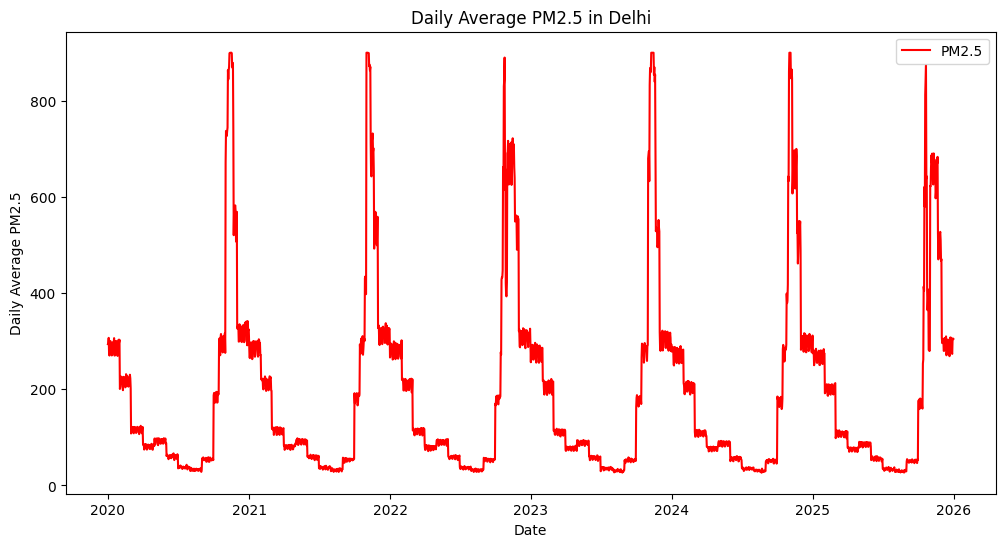

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(daily_delhi['date'], daily_delhi['pm25'], label='PM2.5', color='red')
plt.xlabel('Date')
plt.ylabel('Daily Average PM2.5')
plt.title('Daily Average PM2.5 in Delhi')
plt.legend()
plt.show()

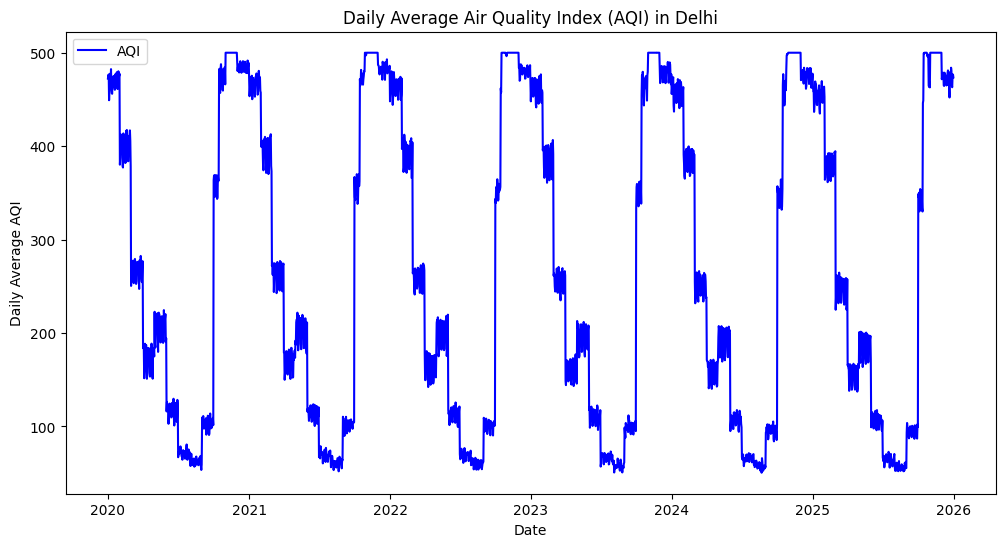

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(daily_delhi['date'], daily_delhi['aqi'], label='AQI', color='blue')
plt.xlabel('Date')
plt.ylabel('Daily Average AQI')
plt.title('Daily Average Air Quality Index (AQI) in Delhi')
plt.legend()
plt.show()

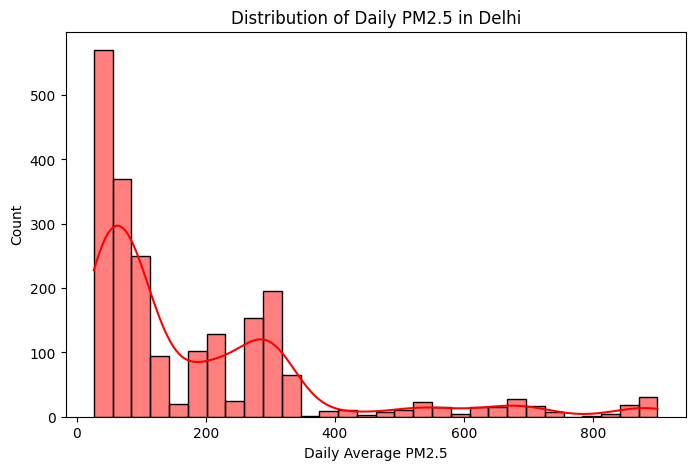

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(daily_delhi['pm25'], bins=30, kde=True, color='red')
plt.xlabel('Daily Average PM2.5')
plt.title('Distribution of Daily PM2.5 in Delhi')
plt.show()

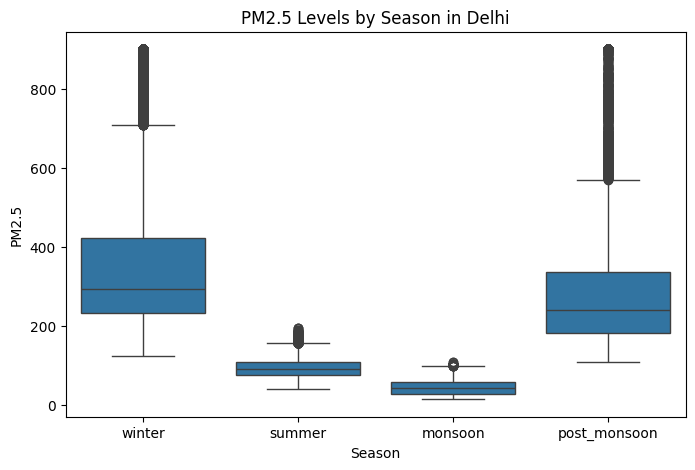

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=delhi_df, x='season', y='pm25')
plt.xlabel('Season')
plt.ylabel('PM2.5')
plt.title('PM2.5 Levels by Season in Delhi')
plt.show()

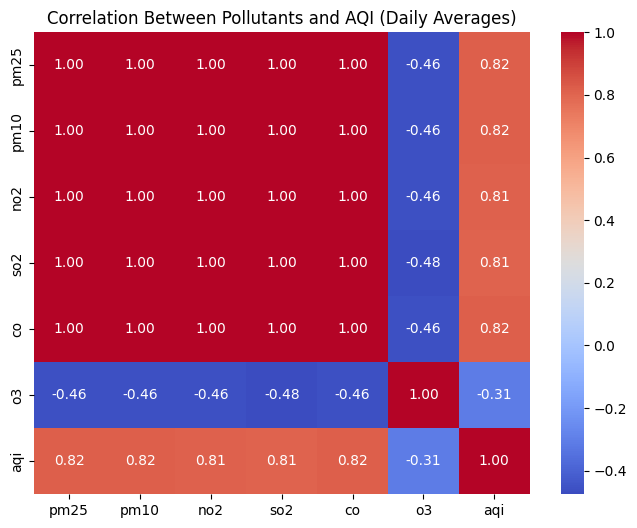

In [15]:
plt.figure(figsize=(8, 6))
corr_cols = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'aqi']
sns.heatmap(daily_delhi[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Pollutants and AQI (Daily Averages)')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
# Features (input variables)
features = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']

X = daily_delhi[features]
y = daily_delhi['aqi']

# Check for missing values just in case
print(X.isna().sum())
print("Missing in y:", y.isna().sum())

pm25    0
pm10    0
no2     0
so2     0
co      0
o3      0
dtype: int64
Missing in y: 0


In [18]:
# Keep only rows where all features and target are present
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2192, 6)
Shape of y: (2192,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 1753
Test samples: 439


In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on test set
y_pred_lr = lr_model.predict(X_test)

In [28]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# MSE first (default squared=True)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = mse_lr ** 0.5  # square root to get RMSE

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R^2:", r2_lr)

Linear Regression Performance:
MAE: 77.77752976312128
RMSE: 91.91980833397167
R^2: 0.6977966793308553


In [29]:
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lr_model.coef_
}).sort_values(by='coefficient', ascending=False)

coef_df

,feature,coefficient
0,pm25,4.327108
1,pm10,0.732002
5,o3,0.402711
2,no2,-0.536355
3,so2,-37.203167
4,co,-96.567613


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R^2:", r2_rf)

Random Forest Performance:
MAE: 1.2752355190367644
RMSE: 2.0607538345075262
R^2: 0.999848108578984


In [33]:
print("Number of raw Delhi records (hourly/point):", len(delhi_df))
print("Number of daily records:", len(daily_delhi))
print("Date range:", daily_delhi['date'].min(), "to", daily_delhi['date'].max())

Number of raw Delhi records (hourly/point): 122752
Number of daily records: 2192
Date range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00
